# Credit Risk Origination — Classification Model

This notebook walks through an end-to-end credit risk modeling pipeline: exploratory analysis, feature engineering, model training with hyperparameter tuning, and evaluation. The dataset contains 1,000 company-level observations with features sourced from SERPRO (corporate structure) and BACEN (credit bureau), alongside a binary target indicating risk outcome.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                      RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, make_scorer)
import lightgbm as lgb
import xgboost as xgb

!pip install catboost
from catboost import CatBoostClassifier
import warnings, time

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


## Exploratory Data Analysis

### Loading the data

In [3]:
df = pd.read_csv('data.csv')
original_features = [c for c in df.columns if c not in ['id', 'target']]

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(original_features)}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nBad rate: {df['target'].mean()*100:.1f}%")
df.head()

Dataset shape: (1000, 30)
Features: 28

Target distribution:
target
0    854
1    146
Name: count, dtype: int64

Bad rate: 14.6%


,id,serpro__company_age_months,serpro__num_owners,serpro__num_owners_added_last_12m,serpro__avg_owner_tenure_months,serpro__num_key_executive_owners,serpro__key_executive_owner_fraction,serpro__num_non_executive_owners,bacen__min_account_age_months,bacen__max_account_age_months,...,bacen__utilization_cc_last_1m,bacen__overdue_ratio_last_1m,bacen__overdue_ratio_cc_last_1m,bacen__over30_ratio_last_1m,bacen__over30_ratio_cc_last_1m,bacen__over60_ratio_last_1m,bacen__over60_ratio_cc_last_1m,bacen__due_in_30_ratio_last_1_month,bacen__due_in_30_ratio_cc_last_1_month,target
0,1,76.175821,1.0,0.0,76.175821,1.0,1.000000,0.0,30.161290,30.161290,...,0.922717,0.0,0.0,0.0,0.0,0.0,0.0,0.017139,0.211413,0
1,2,1.635379,2.0,2.0,1.635379,1.0,0.500000,1.0,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,3,76.704415,3.0,0.0,42.265309,1.0,0.333333,2.0,71.225806,71.225806,...,0.391272,0.0,0.0,0.0,0.0,0.0,0.0,0.124641,0.185158,0
3,4,180.507956,2.0,0.0,180.507956,2.0,1.000000,0.0,0.000000,172.677419,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.755703,0.000000,0
4,5,13.699796,2.0,0.0,13.699796,2.0,1.000000,0.0,12.580645,12.580645,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0


### Target distribution

The target is heavily imbalanced — roughly 85% good vs 15% bad. This is typical for credit origination portfolios and will influence our metric choices and class weighting strategies.

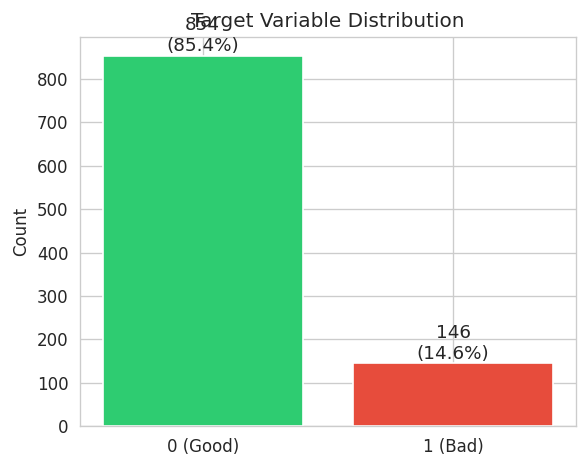

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts()
bars = ax.bar(['0 (Good)', '1 (Bad)'], counts.values, color=['#2ecc71', '#e74c3c'])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
plt.tight_layout()
plt.show()

### Missing values

The missing pattern is informative, not random. Credit card variables (_cc_) have ~38% nulls, general BACEN variables 28–32%. This reflects companies without active credit products — a risk signal in itself. SERPRO variables have no missing data.

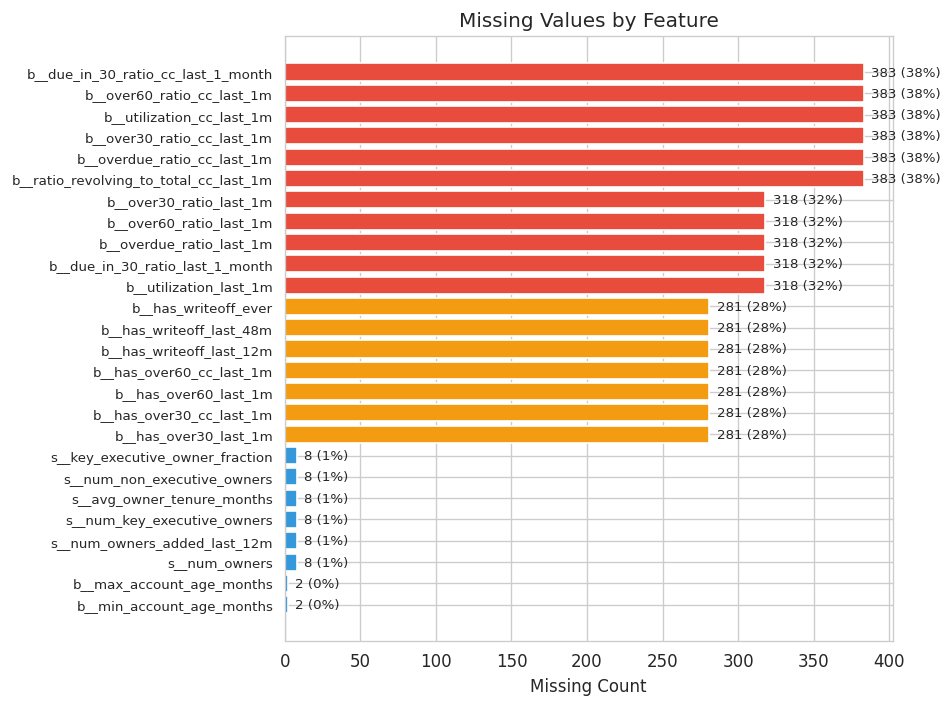

In [5]:
missing = df[original_features].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v/len(df) > 0.3 else '#f39c12' if v/len(df) > 0.2 else '#3498db' for v in missing.values]
ax.barh(range(len(missing)), missing.values, color=colors)
ax.set_yticks(range(len(missing)))
ax.set_yticklabels([c.replace('bacen__','b__').replace('serpro__','s__') for c in missing.index], fontsize=8)
for i, v in enumerate(missing.values):
    ax.text(v+5, i, f'{v} ({v/len(df)*100:.0f}%)', va='center', fontsize=8)
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values by Feature')
plt.tight_layout()
plt.show()

### Distributions by risk class

Bad companies tend to have younger financial accounts, higher credit utilization, and higher delinquency ratios.

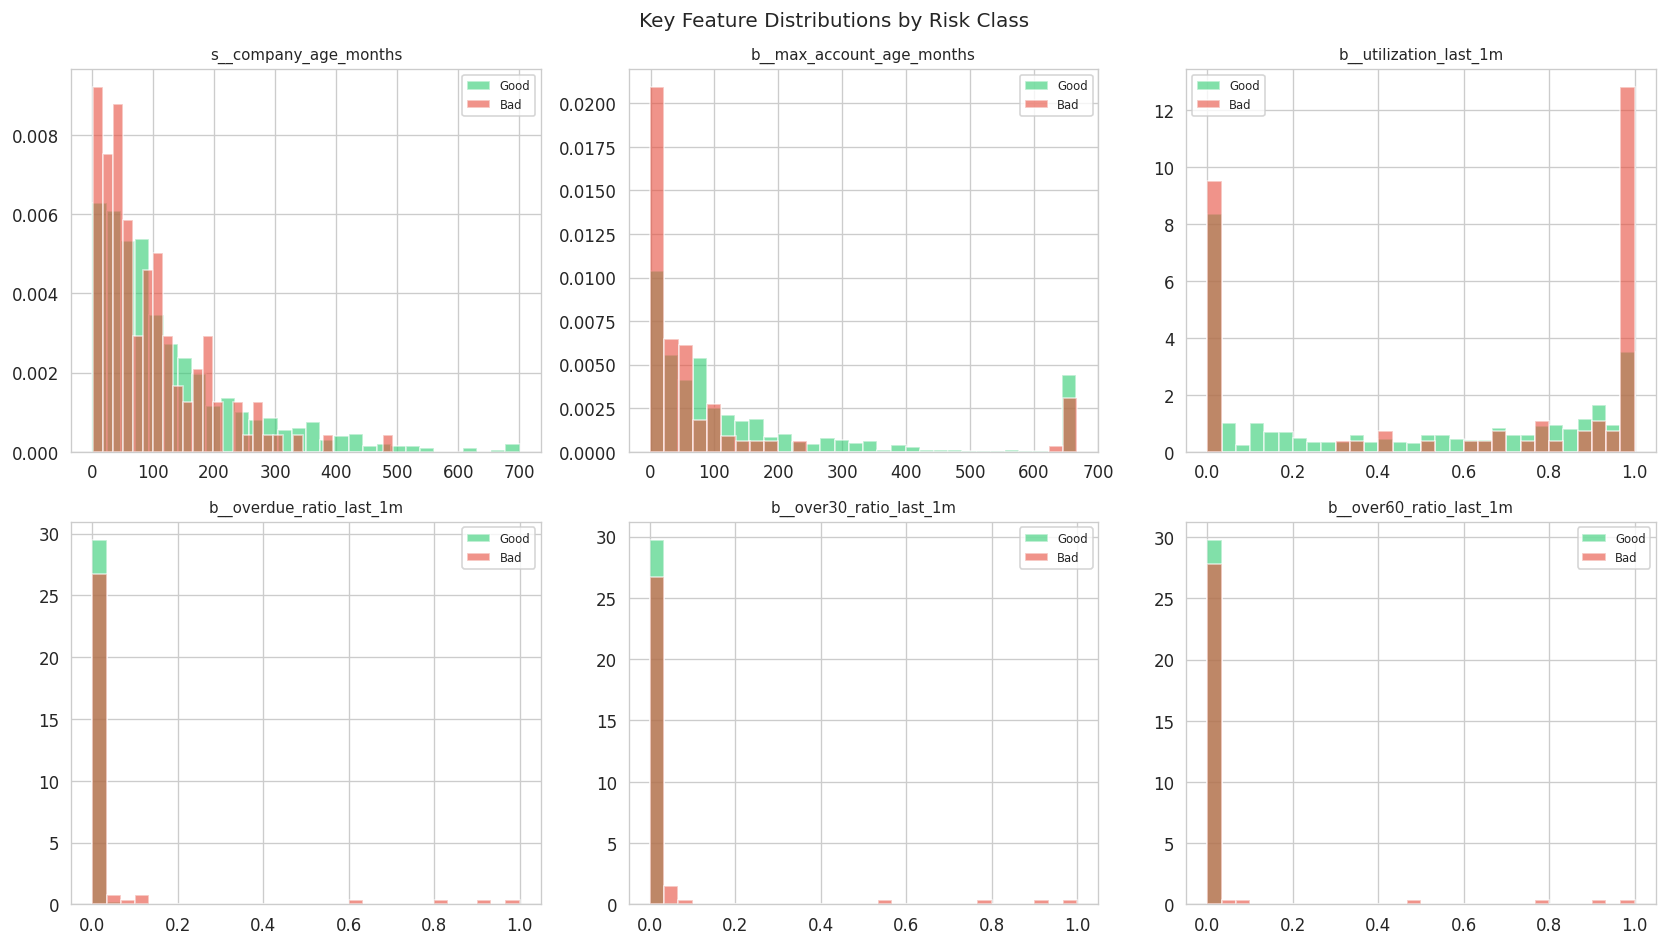

In [6]:
key_vars = ['serpro__company_age_months', 'bacen__max_account_age_months',
            'bacen__utilization_last_1m', 'bacen__overdue_ratio_last_1m',
            'bacen__over30_ratio_last_1m', 'bacen__over60_ratio_last_1m']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var in zip(axes.ravel(), key_vars):
    for tval, color, label in [(0, '#2ecc71', 'Good'), (1, '#e74c3c', 'Bad')]:
        data = df.loc[df['target']==tval, var].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    short = var.replace('bacen__','b__').replace('serpro__','s__')
    ax.set_title(short, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle('Key Feature Distributions by Risk Class', fontsize=12)
plt.tight_layout()
plt.show()

### Bad rate by delinquency flags

Binary delinquency indicators show clear discriminating power. Companies with write-off history in the last 48 months carry substantially higher default rates.

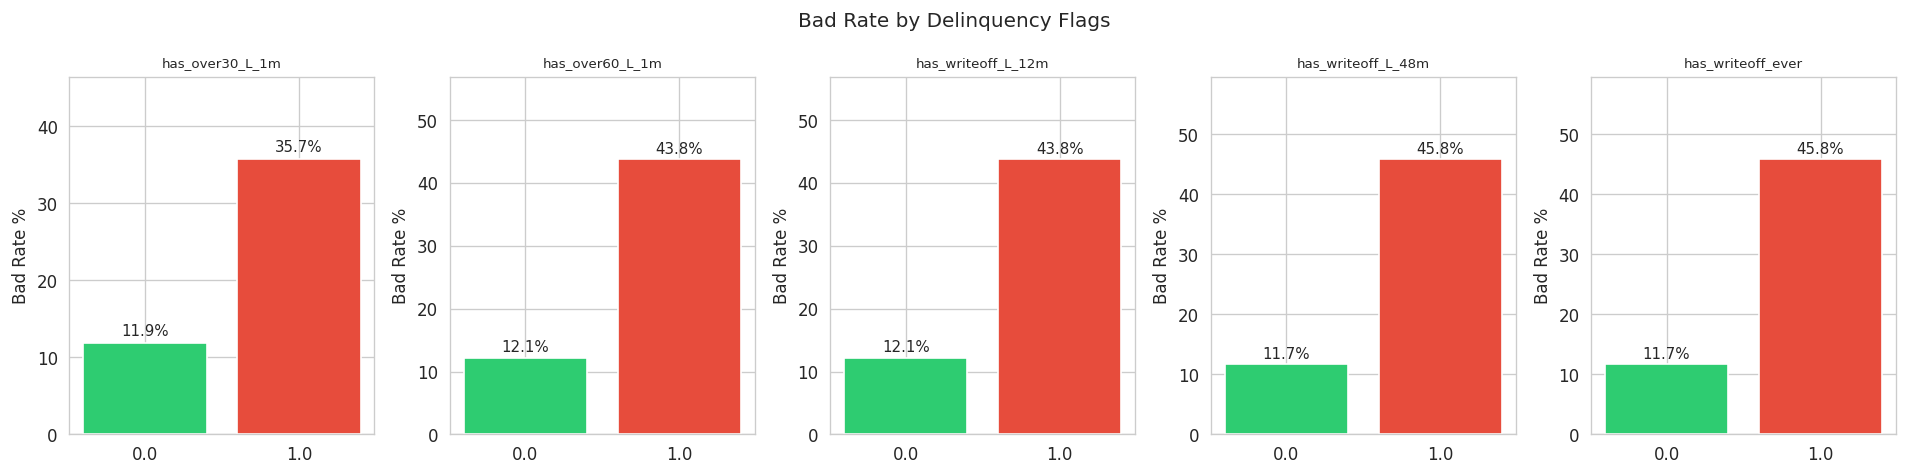

In [7]:
flag_vars = ['bacen__has_over30_last_1m', 'bacen__has_over60_last_1m',
             'bacen__has_writeoff_last_12m', 'bacen__has_writeoff_last_48m', 'bacen__has_writeoff_ever']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, var in zip(axes, flag_vars):
    ct = df.groupby(var)['target'].mean() * 100
    bars = ax.bar(ct.index.astype(str), ct.values, color=['#2ecc71', '#e74c3c'][:len(ct)])
    for b, v in zip(bars, ct.values):
        ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=9)
    ax.set_title(var.replace('bacen__','').replace('_last','_L'), fontsize=8)
    ax.set_ylabel('Bad Rate %')
    ax.set_ylim(0, max(ct.values)*1.3 if len(ct) > 0 else 50)
plt.suptitle('Bad Rate by Delinquency Flags', fontsize=12)
plt.tight_layout()
plt.show()

### Correlation with target

Spearman correlation reveals two groups of predictive variables: corporate structure (number of owners, executive owners) with negative correlation (more owners → lower risk), and credit history (write-offs, delinquency) with positive correlation.

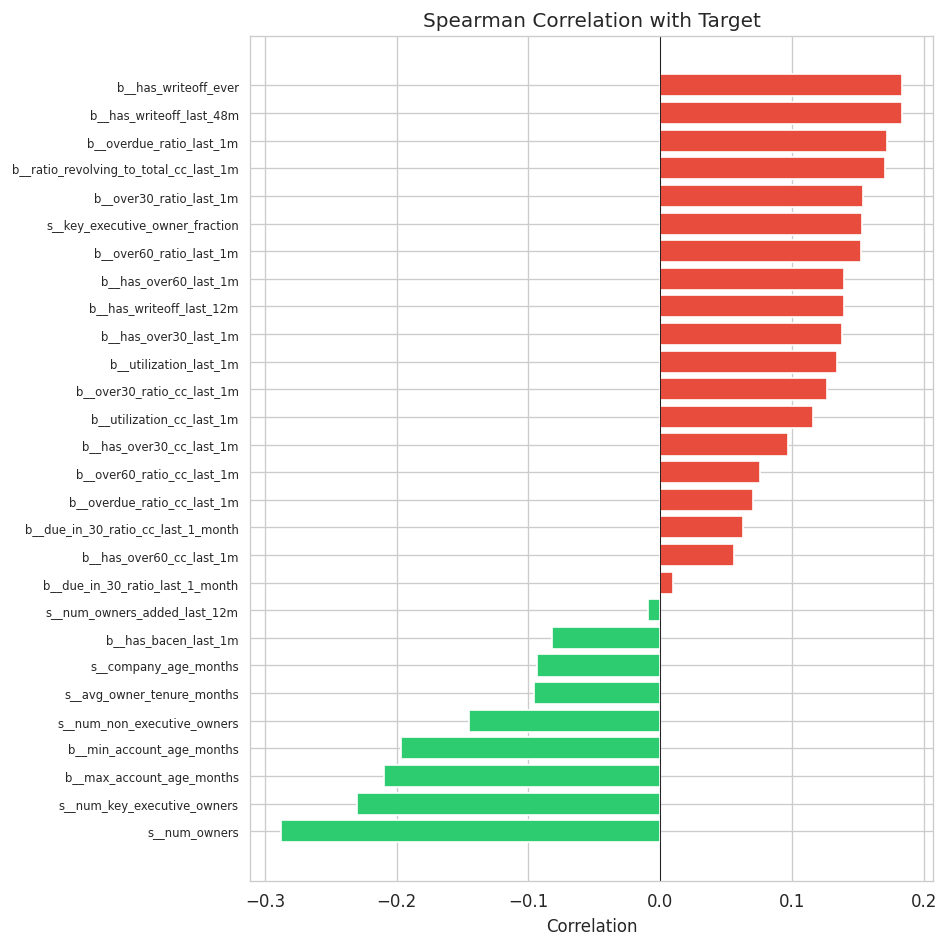

In [8]:
corr_target = df[original_features].corrwith(df['target'], method='spearman').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
ax.barh(range(len(corr_target)), corr_target.values, color=colors)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels([c.replace('bacen__','b__').replace('serpro__','s__') for c in corr_target.index], fontsize=7)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Spearman Correlation with Target')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

### Correlation matrix

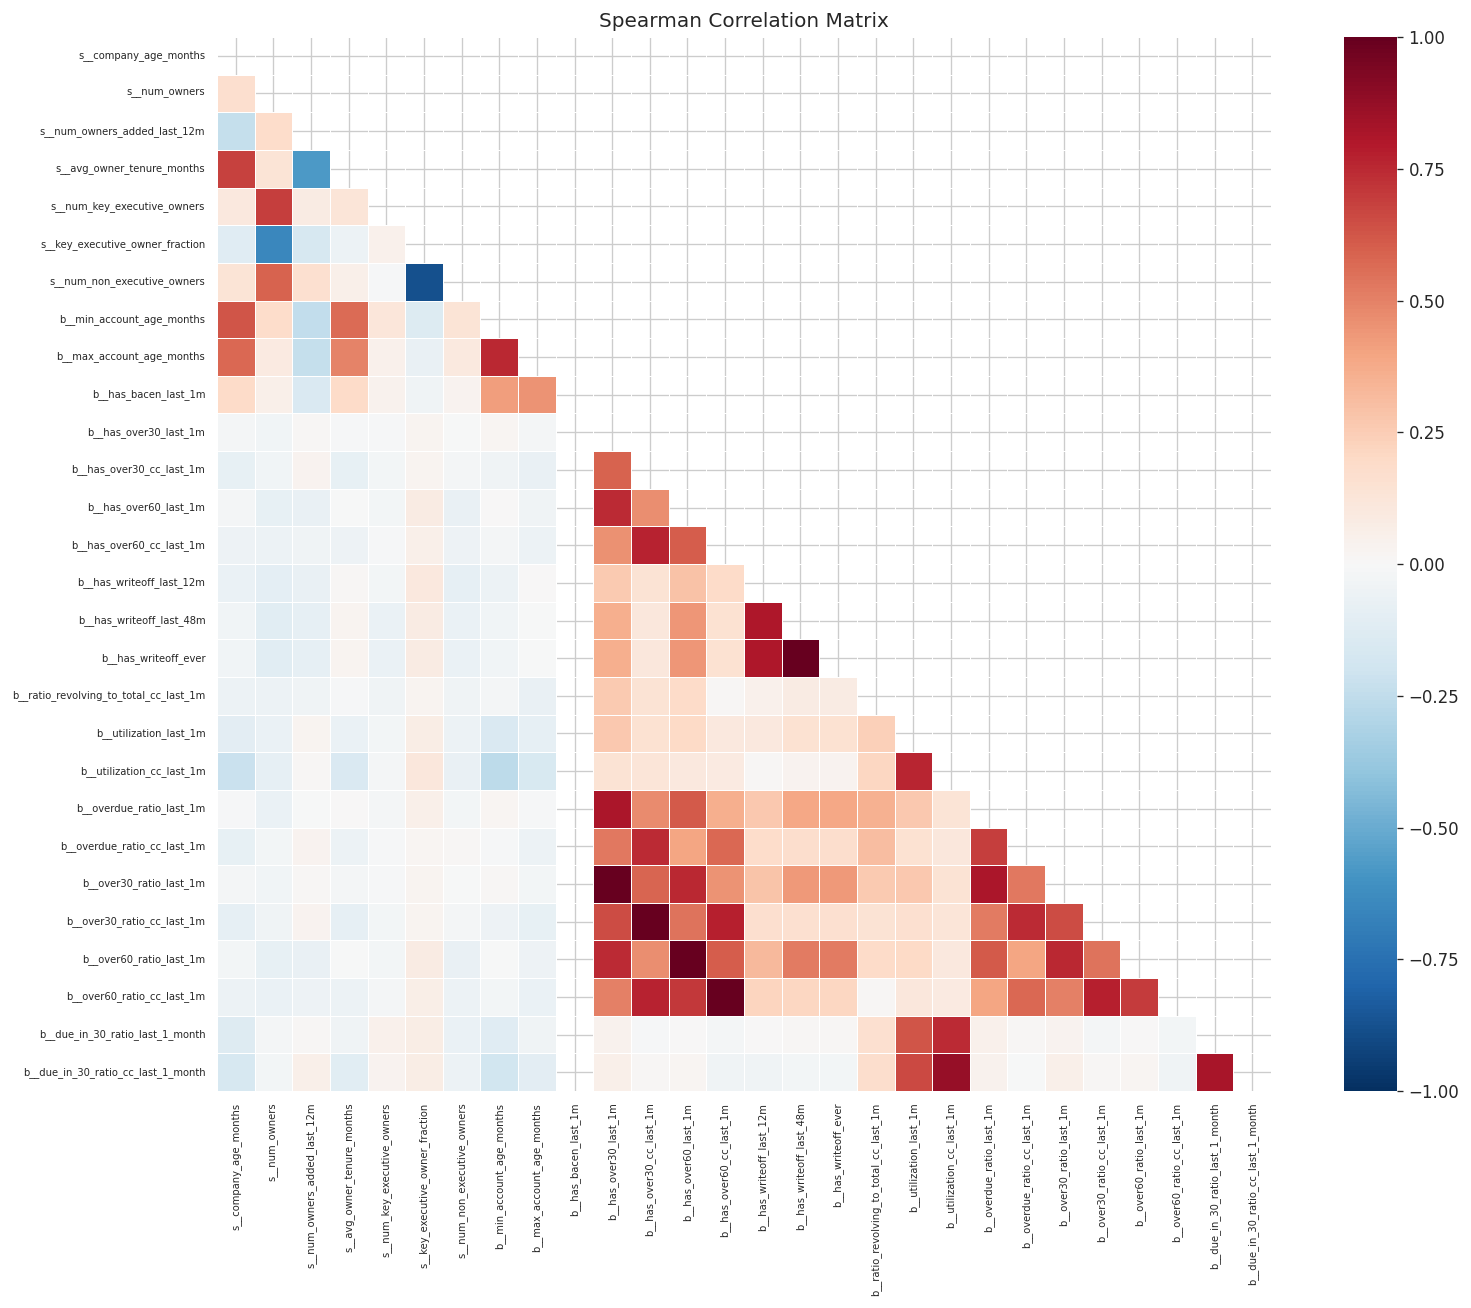

In [9]:
numeric_cols = df[original_features].select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace('bacen__','b__').replace('serpro__','s__') for c in corr.columns],
            yticklabels=[c.replace('bacen__','b__').replace('serpro__','s__') for c in corr.columns],
            ax=ax, annot=False, linewidths=0.5, square=True)
ax.set_title('Spearman Correlation Matrix')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

### Statistical tests

Mann-Whitney U tests confirm that 22 out of 28 features differ significantly between good and bad companies (p < 0.05). Chi-squared tests on the binary BACEN flags validate the association with the target.

In [10]:
# Mann-Whitney U tests
mw_results = []
for f in original_features:
    good = df.loc[df['target']==0, f].dropna()
    bad = df.loc[df['target']==1, f].dropna()
    if len(good) > 5 and len(bad) > 5:
        stat, pval = stats.mannwhitneyu(good, bad, alternative='two-sided')
        mw_results.append({'variable': f, 'U_statistic': stat, 'p_value': pval,
                          'median_good': good.median(), 'median_bad': bad.median()})

mw_df = pd.DataFrame(mw_results).sort_values('p_value')
mw_df['significant'] = mw_df['p_value'] < 0.05
print(f"Significant features (p<0.05): {mw_df['significant'].sum()} out of {len(mw_df)}")
print(f"\nTop 10 most discriminating:")
mw_df.head(10)[['variable', 'p_value', 'median_good', 'median_bad']].to_string(index=False)
mw_df.head(10)

Significant features (p<0.05): 22 out of 28

Top 10 most discriminating:


,variable,U_statistic,p_value,median_good,median_bad,significant
1,serpro__num_owners,88939.5,1.435569e-19,2.000000,1.000000,True
4,serpro__num_key_executive_owners,81381.0,4.420108e-13,1.000000,1.000000,True
8,bacen__max_account_age_months,83490.5,3.618896e-11,74.483871,29.064516,True
7,bacen__min_account_age_months,82178.0,5.019185e-10,48.758065,11.951613,True
15,bacen__has_writeoff_last_48m,25991.5,8.482565e-07,0.000000,0.000000,True
16,bacen__has_writeoff_ever,25991.5,8.482565e-07,0.000000,0.000000,True
5,serpro__key_executive_owner_fraction,49136.5,1.377522e-06,1.000000,1.000000,True
6,serpro__num_non_executive_owners,72964.0,4.655426e-06,0.000000,0.000000,True
20,bacen__overdue_ratio_last_1m,21467.5,7.057034e-06,0.000000,0.000000,True
17,bacen__ratio_revolving_to_total_cc_last_1m,14157.5,2.328281e-05,0.000000,0.000000,True


In [11]:
# Chi-squared tests on binary flags
binary_vars = ['bacen__has_bacen_last_1m', 'bacen__has_over30_last_1m', 'bacen__has_over60_last_1m',
               'bacen__has_over30_cc_last_1m', 'bacen__has_over60_cc_last_1m',
               'bacen__has_writeoff_last_12m', 'bacen__has_writeoff_last_48m', 'bacen__has_writeoff_ever']

chi2_results = []
for v in binary_vars:
    ct = pd.crosstab(df[v].fillna(-1), df['target'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    chi2_results.append({'variable': v, 'chi2': round(chi2, 2), 'p_value': f'{p:.2e}', 'dof': dof})

pd.DataFrame(chi2_results).sort_values('chi2', ascending=False)

,variable,chi2,p_value,dof
6,bacen__has_writeoff_last_48m,28.42,6.75e-07,2
7,bacen__has_writeoff_ever,28.42,6.75e-07,2
2,bacen__has_over60_last_1m,19.26,6.58e-05,2
5,bacen__has_writeoff_last_12m,19.26,6.58e-05,2
1,bacen__has_over30_last_1m,18.96,7.65e-05,2
3,bacen__has_over30_cc_last_1m,12.70,1.75e-03,2
4,bacen__has_over60_cc_last_1m,8.73,1.27e-02,2
0,bacen__has_bacen_last_1m,6.18,1.29e-02,1


## Feature Engineering

We create 33 new features organized into 7 domain-driven categories. Each is motivated by credit risk fundamentals rather than blind transformation.

### Missing-as-feature

Absence of BACEN data isn't random — it signals companies without active credit products, which is a risk profile on its own.

In [12]:
fe = df.copy()

# Missing indicators
fe['fe__has_no_bacen_data'] = fe['bacen__has_bacen_last_1m'].apply(lambda x: 1 if x == 0 else 0)
fe['fe__missing_cc_data'] = fe['bacen__utilization_cc_last_1m'].isnull().astype(int)
fe['fe__missing_bacen_ratios'] = fe['bacen__utilization_last_1m'].isnull().astype(int)

### Age and maturity

Company age and financial account age serve as proxies for track record. Younger companies with no credit history represent higher uncertainty.

In [13]:
fe['fe__company_age_years'] = fe['serpro__company_age_months'] / 12
fe['fe__is_young_company'] = (fe['serpro__company_age_months'] < 24).astype(int)
fe['fe__is_very_young_company'] = (fe['serpro__company_age_months'] < 6).astype(int)
fe['fe__account_age_range'] = fe['bacen__max_account_age_months'] - fe['bacen__min_account_age_months']
fe['fe__company_vs_max_account_age'] = fe['serpro__company_age_months'] - fe['bacen__max_account_age_months']
fe['fe__account_to_company_age_ratio'] = np.where(
    fe['serpro__company_age_months'] > 0,
    fe['bacen__max_account_age_months'] / fe['serpro__company_age_months'], 0)

### Corporate governance

Ownership structure matters. Sole-owner companies turned out to have the highest single-feature correlation with the target (ρ = 0.287).

In [14]:
fe['fe__is_sole_owner'] = (fe['serpro__num_owners'] == 1).astype(int)
fe['fe__owners_added_ratio'] = np.where(
    fe['serpro__num_owners'] > 0,
    fe['serpro__num_owners_added_last_12m'] / fe['serpro__num_owners'], 0)
fe['fe__all_owners_are_new'] = (
    (fe['serpro__num_owners_added_last_12m'] == fe['serpro__num_owners']) &
    (fe['serpro__num_owners'] > 0)).astype(int)
fe['fe__owner_tenure_vs_company_age'] = np.where(
    fe['serpro__company_age_months'] > 0,
    fe['serpro__avg_owner_tenure_months'] / fe['serpro__company_age_months'], 0)
fe['fe__has_non_executive_owners'] = (fe['serpro__num_non_executive_owners'] > 0).astype(int)

### Composite credit stress scores

Instead of treating each delinquency flag independently, we build weighted composite scores that capture the overall severity of credit distress.

In [15]:
fe['fe__any_delinquency'] = (
    (fe['bacen__has_over30_last_1m'] == 1) | (fe['bacen__has_over60_last_1m'] == 1)).astype(int)
fe['fe__severe_delinquency'] = (
    (fe['bacen__has_over60_last_1m'] == 1) | (fe['bacen__has_writeoff_last_12m'] == 1)).astype(int)
fe['fe__delinquency_score'] = (
    fe['bacen__has_over30_last_1m'].fillna(0) * 1 +
    fe['bacen__has_over60_last_1m'].fillna(0) * 2 +
    fe['bacen__has_writeoff_last_12m'].fillna(0) * 3 +
    fe['bacen__has_writeoff_last_48m'].fillna(0) * 2 +
    fe['bacen__has_writeoff_ever'].fillna(0) * 1)
fe['fe__writeoff_escalation'] = (
    fe['bacen__has_writeoff_last_12m'].fillna(0) * 3 +
    fe['bacen__has_writeoff_last_48m'].fillna(0) * 2 +
    fe['bacen__has_writeoff_ever'].fillna(0) * 1)

### Utilization behavior

High credit utilization (>80%) often signals financial stress. We also capture excess reliance on revolving credit card lines versus total credit.

In [16]:
fe['fe__high_utilization'] = (fe['bacen__utilization_last_1m'] > 0.8).astype(int)
fe['fe__very_high_utilization'] = (fe['bacen__utilization_last_1m'] > 0.95).astype(int)
fe['fe__cc_utilization_excess'] = np.where(
    fe['bacen__utilization_last_1m'] > 0,
    fe['bacen__utilization_cc_last_1m'] / (fe['bacen__utilization_last_1m'] + 1e-6), 0)
fe['fe__overdue_intensity'] = (
    fe['bacen__overdue_ratio_last_1m'].fillna(0) +
    fe['bacen__over30_ratio_last_1m'].fillna(0) +
    fe['bacen__over60_ratio_last_1m'].fillna(0))
fe['fe__overdue_intensity_cc'] = (
    fe['bacen__overdue_ratio_cc_last_1m'].fillna(0) +
    fe['bacen__over30_ratio_cc_last_1m'].fillna(0) +
    fe['bacen__over60_ratio_cc_last_1m'].fillna(0))

### Domain interactions

These capture compound risk profiles that individual variables can't express — a young sole-owner company with active delinquency is a very different risk than each factor alone.

In [17]:
fe['fe__young_company_x_delinquency'] = fe['fe__is_young_company'] * fe['fe__delinquency_score']
fe['fe__sole_owner_x_young'] = fe['fe__is_sole_owner'] * fe['fe__is_young_company']
fe['fe__high_util_x_delinquency'] = fe['fe__high_utilization'] * fe['fe__any_delinquency']
fe['fe__no_bacen_x_young'] = fe['fe__has_no_bacen_data'] * fe['fe__is_young_company']

### Additional ratios and log transforms

Log transforms on age variables reduce skewness and capture diminishing marginal returns of tenure on risk reduction.

In [18]:
fe['fe__revolving_and_overdue'] = (
    fe['bacen__ratio_revolving_to_total_cc_last_1m'].fillna(0) *
    fe['bacen__overdue_ratio_cc_last_1m'].fillna(0))
fe['fe__due30_minus_overdue'] = (
    fe['bacen__due_in_30_ratio_last_1_month'].fillna(0) -
    fe['bacen__overdue_ratio_last_1m'].fillna(0))

for col in ['serpro__company_age_months', 'bacen__max_account_age_months',
            'bacen__min_account_age_months', 'serpro__avg_owner_tenure_months']:
    fe[f'fe__log_{col.split("__")[1]}'] = np.log1p(fe[col].fillna(0))

new_features = [c for c in fe.columns if c.startswith('fe__')]
all_features = original_features + new_features

print(f"Original features:   {len(original_features)}")
print(f"Engineered features: {len(new_features)}")
print(f"Total features:      {len(all_features)}")

Original features:   28
Engineered features: 33
Total features:      61


### Checking the new features' correlation with target

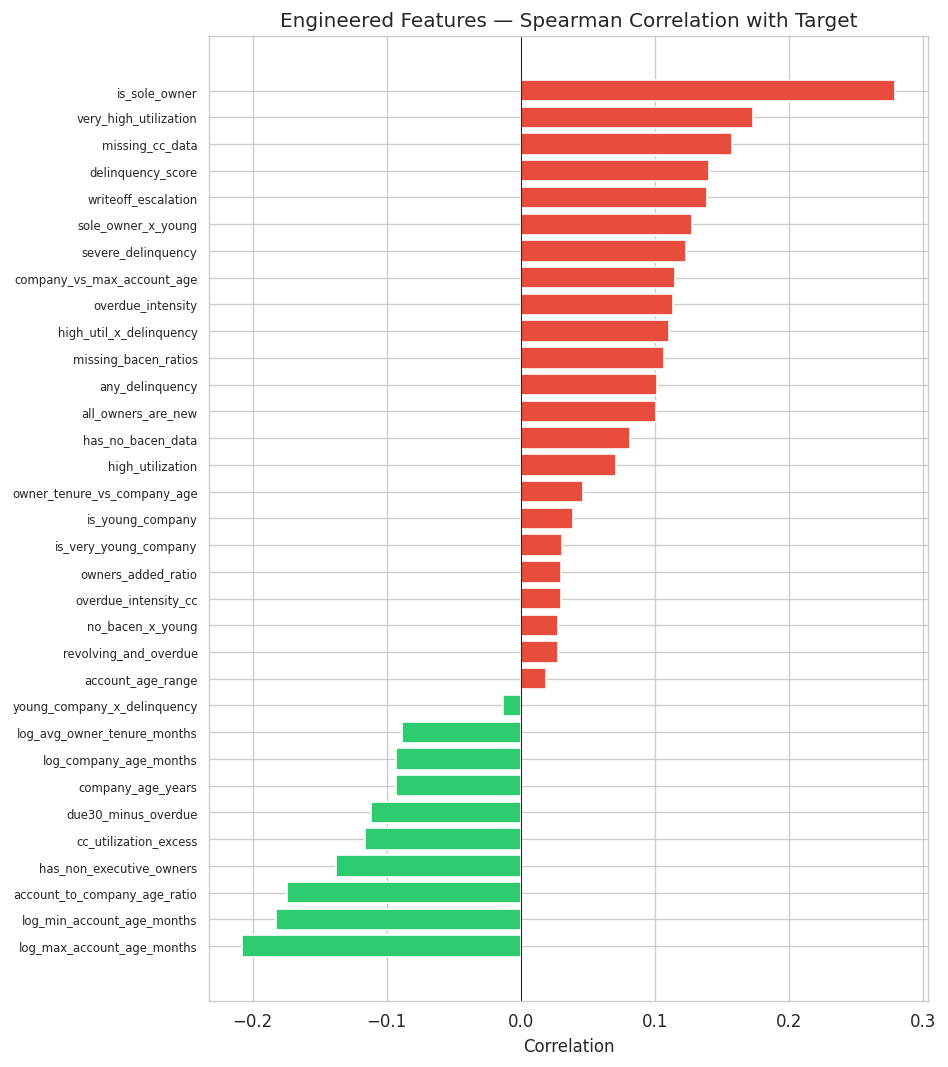

In [19]:
corr_new = fe[new_features + ['target']].corr(method='spearman')['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors_corr = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_new.values]
ax.barh(range(len(corr_new)), corr_new.values, color=colors_corr)
ax.set_yticks(range(len(corr_new)))
ax.set_yticklabels([f.replace('fe__','') for f in corr_new.index], fontsize=7)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Engineered Features — Spearman Correlation with Target')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

## Model Training and Hyperparameter Optimization

We train six models, each with a RandomizedSearchCV (15 iterations, 3-fold inner CV) to find reasonable hyperparameters, then evaluate with 5-fold stratified outer CV for unbiased performance estimates.

In [20]:
X = fe[all_features]
y = fe['target']
scale_weight = len(y[y==0]) / len(y[y==1])

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(roc_auc_score, needs_proba=True)
N_ITER = 15

### Defining the search spaces

Each model gets a parameter grid tailored to its mechanics. We keep the grids focused — 15 iterations isn't much, so we concentrate on the parameters that matter most for generalization on small datasets.

In [21]:
hpo_configs = {
    'LightGBM': {
        'model': lgb.LGBMClassifier(objective='binary', verbose=-1, random_state=42,
                                     scale_pos_weight=scale_weight),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],
            'num_leaves': [7, 15, 31, 50],
            'min_child_samples': [10, 20, 30, 50],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.01, 0.1, 1.0],
            'reg_lambda': [0, 0.1, 1.0, 5.0],
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(objective='binary:logistic', verbosity=0, random_state=42,
                                    scale_pos_weight=scale_weight, eval_metric='auc'),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],
            'min_child_weight': [5, 10, 20, 30],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.01, 0.1, 1.0],
            'reg_lambda': [0, 0.1, 1.0, 5.0],
            'gamma': [0, 0.1, 0.5, 1.0],
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0, random_seed=42, auto_class_weights='Balanced'),
        'params': {
            'iterations': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'depth': [3, 4, 5, 6],
            'l2_leaf_reg': [1, 3, 5, 10],
            'min_data_in_leaf': [5, 10, 20, 30],
            'bagging_temperature': [0, 0.5, 1.0, 2.0],
            'random_strength': [0, 0.5, 1.0, 2.0],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [200, 300, 500, 800],
            'max_depth': [4, 5, 6, 8, 10, None],
            'min_samples_leaf': [5, 10, 15, 20, 30],
            'min_samples_split': [5, 10, 15, 20],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
        }
    },
    'Extra Trees': {
        'model': ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [200, 300, 500, 800],
            'max_depth': [4, 5, 6, 8, 10, None],
            'min_samples_leaf': [5, 10, 15, 20, 30],
            'min_samples_split': [5, 10, 15, 20],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
        }
    },
    'Logistic Regression': {
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
        ]),
        'params': {
            'model__C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs', 'saga'],
            'imputer__strategy': ['median', 'mean'],
        }
    },
}

### Running the optimization loop

In [22]:
results_before = {}
results_after = {}
best_models = {}
best_params = {}
all_probs_after = {}

colors_map = {
    'LightGBM': '#2ecc71', 'XGBoost': '#3498db', 'CatBoost': '#9b59b6',
    'Random Forest': '#e67e22', 'Extra Trees': '#f39c12', 'Logistic Regression': '#e74c3c'
}

for name, config in hpo_configs.items():
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")

    model = config['model']
    params = config['params']

    # Before HPO
    t0 = time.time()
    try:
        probs_b = cross_val_predict(model, X, y, cv=cv_outer, method='predict_proba')[:, 1]
        auc_b = roc_auc_score(y, probs_b)
        fpr_b, tpr_b, _ = roc_curve(y, probs_b)
        ks_b = max(tpr_b - fpr_b)
        ap_b = average_precision_score(y, probs_b)
        results_before[name] = {'AUC': auc_b, 'Gini': 2*auc_b-1, 'KS': ks_b, 'AP': ap_b}
        print(f"  BEFORE:  AUC={auc_b:.4f}  Gini={2*auc_b-1:.4f}  KS={ks_b:.4f}")
    except Exception as e:
        print(f"  BEFORE:  ERROR - {e}")
        results_before[name] = {'AUC': 0, 'Gini': 0, 'KS': 0, 'AP': 0}
        auc_b = 0

    # HPO
    search = RandomizedSearchCV(model, params, n_iter=N_ITER, scoring=scorer,
                                 cv=cv_inner, random_state=42, n_jobs=-1, verbose=0, refit=True)
    search.fit(X, y)
    best_models[name] = search.best_estimator_
    best_params[name] = search.best_params_

    # After HPO
    probs_a = cross_val_predict(search.best_estimator_, X, y, cv=cv_outer, method='predict_proba')[:, 1]
    auc_a = roc_auc_score(y, probs_a)
    fpr_a, tpr_a, _ = roc_curve(y, probs_a)
    ks_a = max(tpr_a - fpr_a)
    ap_a = average_precision_score(y, probs_a)
    results_after[name] = {'AUC': auc_a, 'Gini': 2*auc_a-1, 'KS': ks_a, 'AP': ap_a}
    all_probs_after[name] = probs_a

    t1 = time.time()
    delta = (auc_a - auc_b) / auc_b * 100 if auc_b > 0 else 0
    print(f"  AFTER:   AUC={auc_a:.4f}  Gini={2*auc_a-1:.4f}  KS={ks_a:.4f}")
    print(f"  CHANGE:  {'+' if delta >= 0 else ''}{delta:.2f}%  ({t1-t0:.1f}s)")
    print(f"  PARAMS:  {search.best_params_}")


───────────────────────────────────────────────────────
  LightGBM
───────────────────────────────────────────────────────
  BEFORE:  AUC=0.7844  Gini=0.5688  KS=0.4650
  AFTER:   AUC=0.7918  Gini=0.5837  KS=0.4576
  CHANGE:  +0.95%  (11.5s)
  PARAMS:  {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  BEFORE:  AUC=0.7734  Gini=0.5467  KS=0.4304
  AFTER:   AUC=0.7937  Gini=0.5874  KS=0.4673
  CHANGE:  +2.63%  (18.8s)
  PARAMS:  {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.7}

───────────────────────────────────────────────────────
  CatBoost
───────────────────────────────────────────────────────
  BEFORE

## Model Comparison

### Final ranking

In [23]:
ranking = sorted(results_after.items(), key=lambda x: x[1]['AUC'], reverse=True)
print("Final Ranking (after HPO):\n")
for i, (name, r) in enumerate(ranking, 1):
    before = results_before.get(name, {}).get('AUC', 0)
    delta = r['AUC'] - before
    print(f"  {i}. {name:25s}  AUC={r['AUC']:.4f}  Gini={r['Gini']:.4f}  "
          f"KS={r['KS']:.4f}  AP={r['AP']:.4f}  (delta={delta:+.4f})")

Final Ranking (after HPO):

  1. XGBoost                    AUC=0.7937  Gini=0.5874  KS=0.4673  AP=0.3460  (delta=+0.0203)
  2. CatBoost                   AUC=0.7920  Gini=0.5840  KS=0.4624  AP=0.3519  (delta=+0.0097)
  3. LightGBM                   AUC=0.7918  Gini=0.5837  KS=0.4576  AP=0.3466  (delta=+0.0075)
  4. Random Forest              AUC=0.7772  Gini=0.5544  KS=0.4433  AP=0.3185  (delta=+0.0135)
  5. Logistic Regression        AUC=0.7675  Gini=0.5350  KS=0.4342  AP=0.3369  (delta=-0.0065)
  6. Extra Trees                AUC=0.7669  Gini=0.5339  KS=0.4470  AP=0.3376  (delta=+0.0442)


### Before vs after HPO

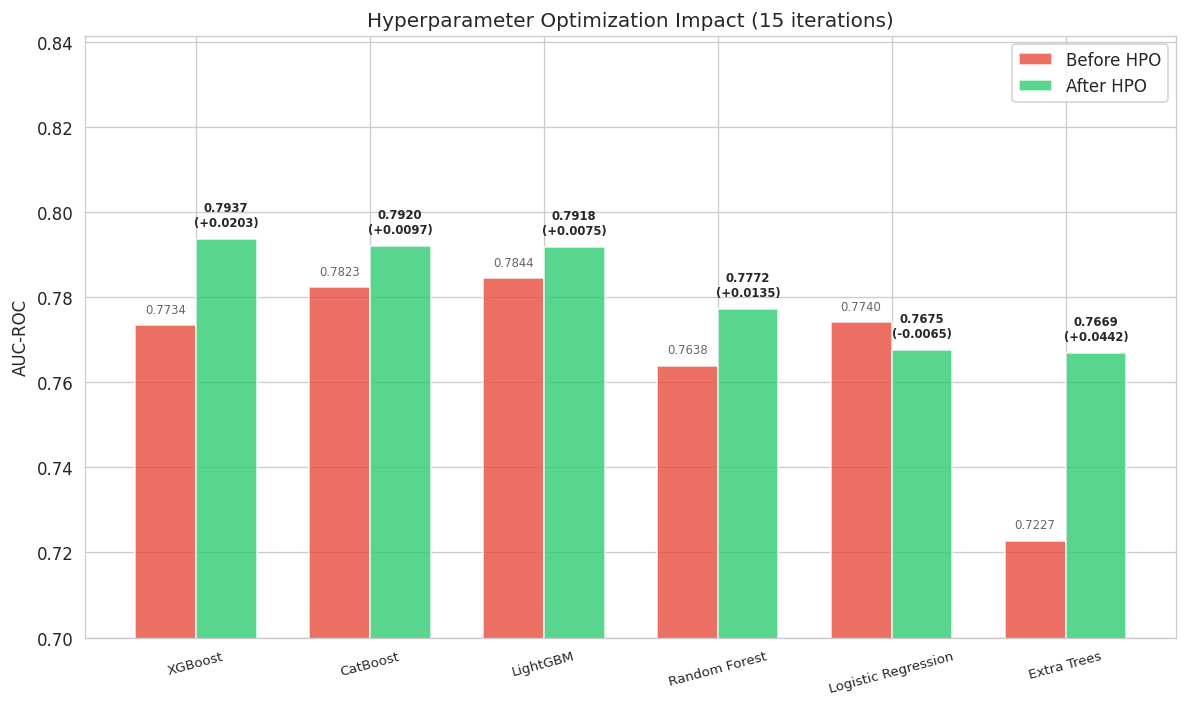

In [24]:
model_names = [name for name, _ in ranking]
aucs_before = [results_before.get(n, {}).get('AUC', 0) for n in model_names]
aucs_after = [results_after[n]['AUC'] for n in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(model_names))
w = 0.35
b1 = ax.bar(x_pos - w/2, aucs_before, w, label='Before HPO', color='#e74c3c', alpha=0.8)
b2 = ax.bar(x_pos + w/2, aucs_after, w, label='After HPO', color='#2ecc71', alpha=0.8)
for i, (bef, aft) in enumerate(zip(aucs_before, aucs_after)):
    delta = aft - bef
    ax.text(i + w/2, aft + 0.003, f'{aft:.4f}\n({delta:+.4f})', ha='center', fontsize=7, fontweight='bold')
    ax.text(i - w/2, bef + 0.003, f'{bef:.4f}', ha='center', fontsize=7, color='#666')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=8, rotation=15)
ax.set_ylabel('AUC-ROC')
ax.set_title('Hyperparameter Optimization Impact (15 iterations)')
ax.legend(fontsize=10)
ax.set_ylim(0.7, max(max(aucs_before), max(aucs_after)) * 1.06)
plt.tight_layout()
plt.show()

### ROC curves

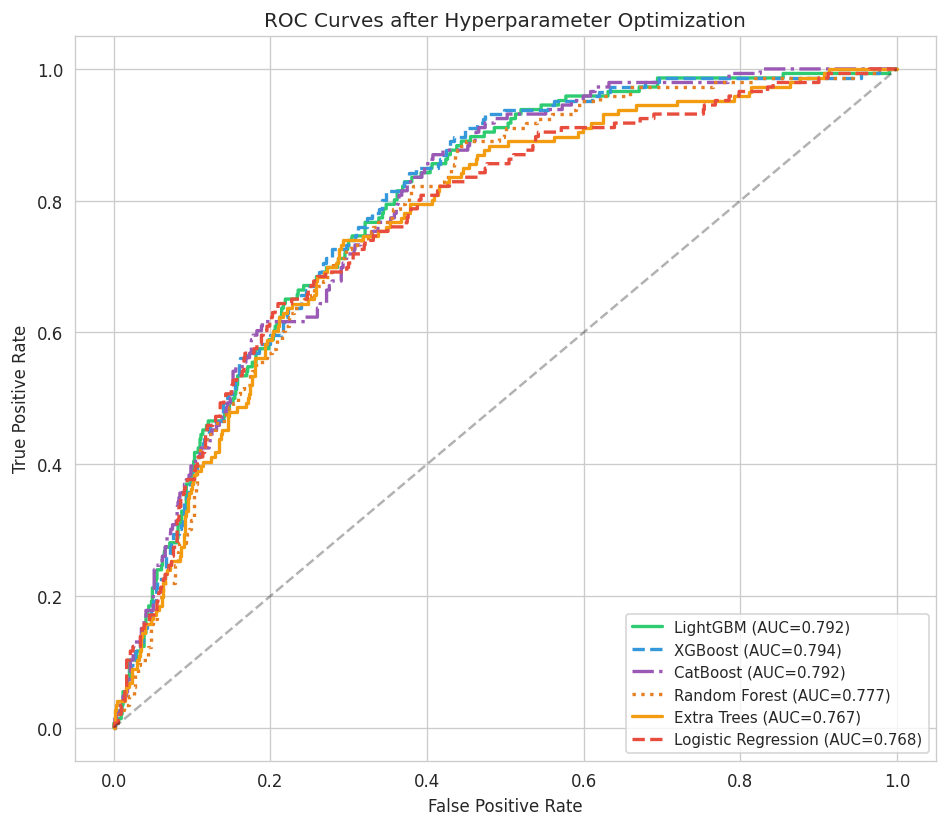

In [25]:
fig, ax = plt.subplots(figsize=(8, 7))
linestyles = ['-', '--', '-.', ':', '-', '--']
for i, (name, probs) in enumerate(all_probs_after.items()):
    fpr, tpr, _ = roc_curve(y, probs)
    auc = results_after[name]['AUC']
    ax.plot(fpr, tpr, linestyle=linestyles[i%len(linestyles)], linewidth=2,
            label=f'{name} (AUC={auc:.3f})', color=colors_map.get(name, '#95a5a6'))
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves after Hyperparameter Optimization')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

### Precision-Recall curves

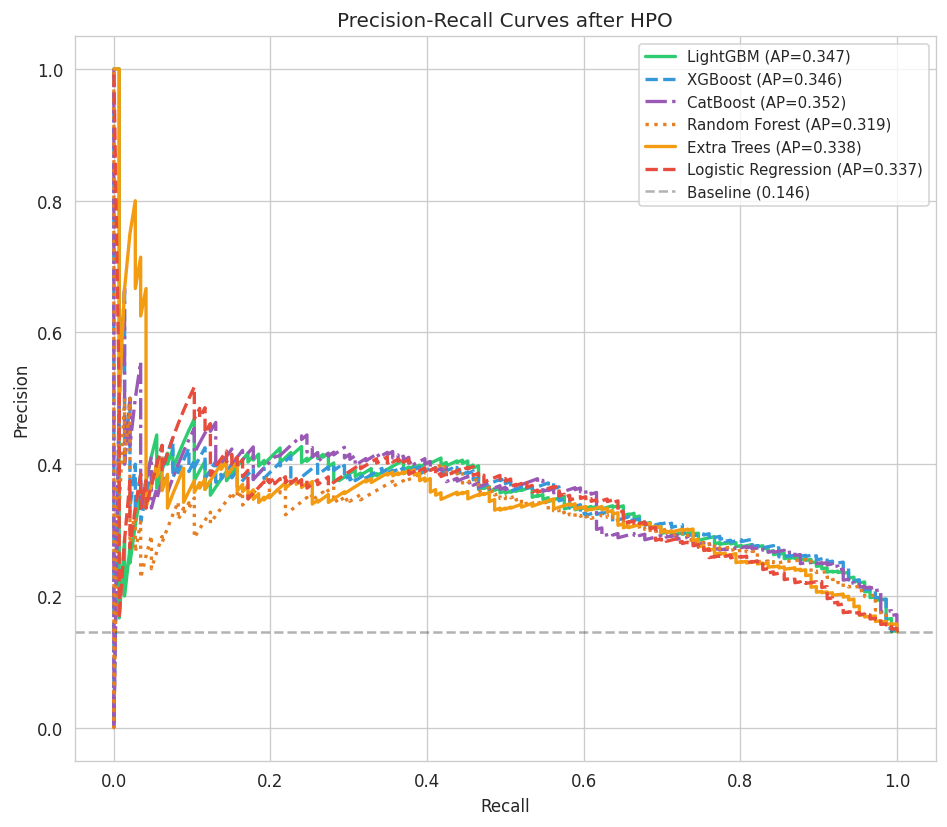

In [26]:
fig, ax = plt.subplots(figsize=(8, 7))
for i, (name, probs) in enumerate(all_probs_after.items()):
    prec, rec, _ = precision_recall_curve(y, probs)
    ap = results_after[name]['AP']
    ax.plot(rec, prec, linestyle=linestyles[i%len(linestyles)], linewidth=2,
            label=f'{name} (AP={ap:.3f})', color=colors_map.get(name, '#95a5a6'))
ax.axhline(y.mean(), color='k', linestyle='--', alpha=0.3, label=f'Baseline ({y.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves after HPO')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Evaluation of the Best Model

In [27]:
best_name = ranking[0][0]
best_probs = all_probs_after[best_name]
print(f"Best model: {best_name}")
print(f"Best params: {best_params[best_name]}")

Best model: XGBoost
Best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.7}


### KS curve and optimal threshold

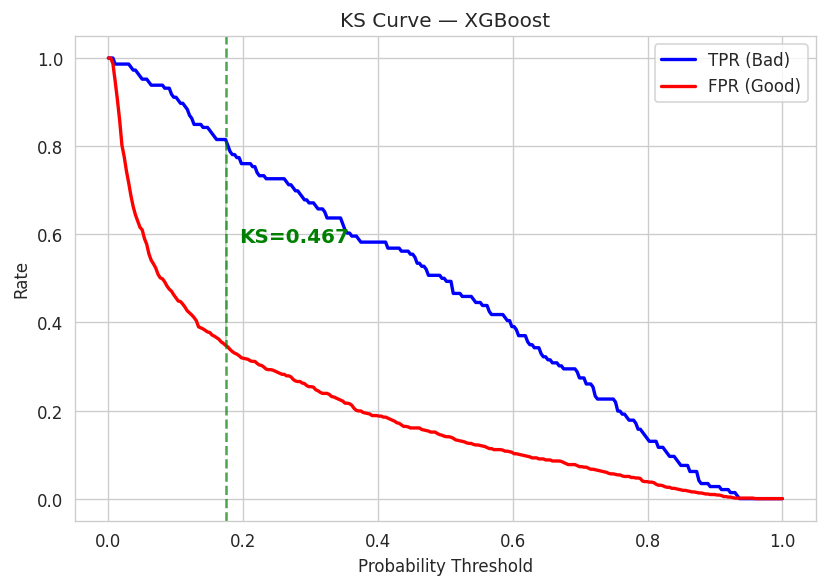

Optimal threshold (KS): 0.1739


In [28]:
thresholds = np.linspace(0, 1, 300)
tpr_v, fpr_v = [], []
for t in thresholds:
    tp = ((best_probs >= t) & (y == 1)).sum()
    fn = ((best_probs < t) & (y == 1)).sum()
    fp = ((best_probs >= t) & (y == 0)).sum()
    tn = ((best_probs < t) & (y == 0)).sum()
    tpr_v.append(tp/(tp+fn) if (tp+fn)>0 else 0)
    fpr_v.append(fp/(fp+tn) if (fp+tn)>0 else 0)
tpr_v, fpr_v = np.array(tpr_v), np.array(fpr_v)
ks_idx = np.argmax(tpr_v - fpr_v)
opt_thresh = thresholds[ks_idx]
ks_val = results_after[best_name]['KS']

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, tpr_v, 'b-', label='TPR (Bad)', linewidth=2)
ax.plot(thresholds, fpr_v, 'r-', label='FPR (Good)', linewidth=2)
ax.axvline(thresholds[ks_idx], color='green', linestyle='--', alpha=0.7)
ax.fill_between([thresholds[ks_idx]]*2, [fpr_v[ks_idx]], [tpr_v[ks_idx]], alpha=0.3, color='green')
ax.text(thresholds[ks_idx]+0.02, (tpr_v[ks_idx]+fpr_v[ks_idx])/2,
        f'KS={ks_val:.3f}', fontsize=12, color='green', fontweight='bold')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Rate')
ax.set_title(f'KS Curve — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold (KS): {opt_thresh:.4f}")

### Decile analysis

The hallmark of a good scorecard: monotonically increasing bad rates from the safest to the riskiest decile.

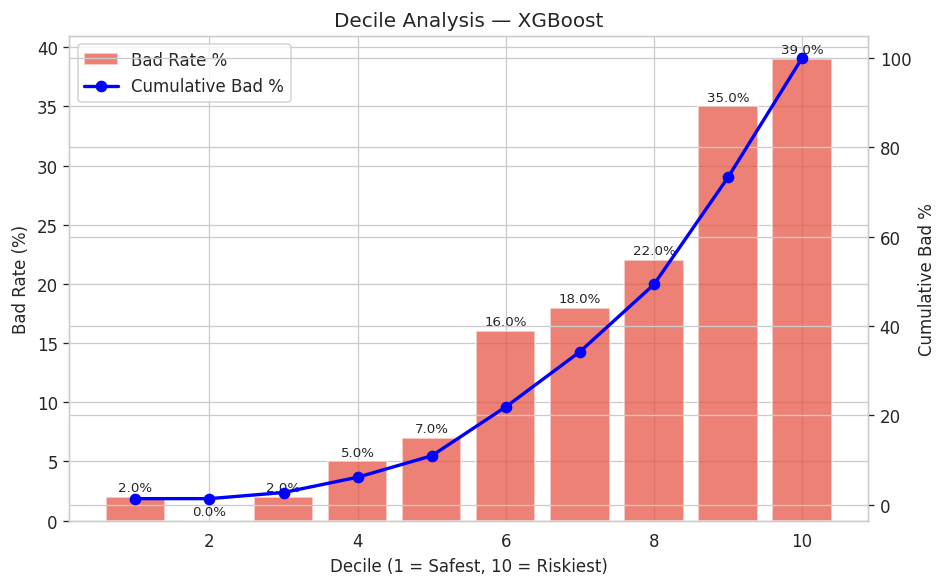

        count  bad_count  avg_prob  bad_rate  cum_bad_pct
decile                                                   
1         100          2  0.010228       2.0     1.369863
2         100          0  0.018888       0.0     1.369863
3         100          2  0.030808       2.0     2.739726
4         100          5  0.051330       5.0     6.164384
5         100          7  0.086670       7.0    10.958904
6         100         16  0.145965      16.0    21.917808
7         100         18  0.250594      18.0    34.246575
8         100         22  0.395177      22.0    49.315068
9         100         35  0.591136      35.0    73.287671
10        100         39  0.810913      39.0   100.000000


In [29]:
df_eval = pd.DataFrame({'prob': best_probs, 'target': y})
df_eval['decile'] = pd.qcut(df_eval['prob'], 10, labels=False, duplicates='drop') + 1
decile_stats = df_eval.groupby('decile').agg(
    count=('target', 'count'), bad_count=('target', 'sum'), avg_prob=('prob', 'mean'))
decile_stats['bad_rate'] = decile_stats['bad_count'] / decile_stats['count'] * 100
decile_stats['cum_bad_pct'] = decile_stats['bad_count'].cumsum() / decile_stats['bad_count'].sum() * 100

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(decile_stats.index, decile_stats['bad_rate'], color='#e74c3c', alpha=0.7, label='Bad Rate %')
for b, v in zip(bars, decile_stats['bad_rate']):
    ax1.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=8)
ax1.set_xlabel('Decile (1 = Safest, 10 = Riskiest)')
ax1.set_ylabel('Bad Rate (%)')
ax2 = ax1.twinx()
ax2.plot(decile_stats.index, decile_stats['cum_bad_pct'], 'b-o', linewidth=2, label='Cumulative Bad %')
ax2.set_ylabel('Cumulative Bad %')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.set_title(f'Decile Analysis — {best_name}')
plt.tight_layout()
plt.show()

print(decile_stats.to_string())

### Confusion matrix and classification report

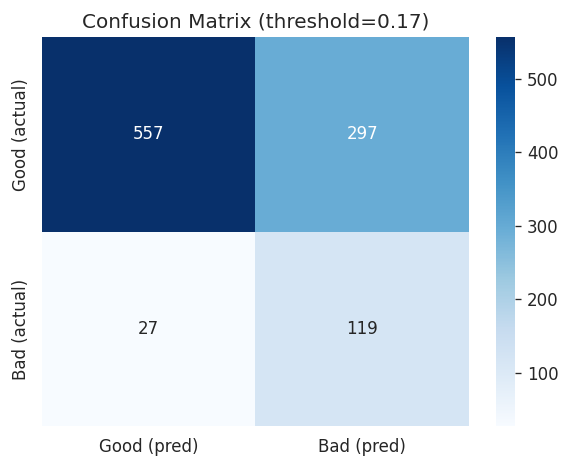

Precision: 0.2861
Recall:    0.8151
F1:        0.4235

              precision    recall  f1-score   support

        Good       0.95      0.65      0.77       854
         Bad       0.29      0.82      0.42       146

    accuracy                           0.68      1000
   macro avg       0.62      0.73      0.60      1000
weighted avg       0.86      0.68      0.72      1000



In [30]:
preds = (best_probs >= opt_thresh).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Good (pred)', 'Bad (pred)'],
            yticklabels=['Good (actual)', 'Bad (actual)'])
ax.set_title(f'Confusion Matrix (threshold={opt_thresh:.2f})')
plt.tight_layout()
plt.show()

print(f"Precision: {precision_score(y, preds):.4f}")
print(f"Recall:    {recall_score(y, preds):.4f}")
print(f"F1:        {f1_score(y, preds):.4f}")
print(f"\n{classification_report(y, preds, target_names=['Good', 'Bad'])}")

### Feature importance

Red bars are engineered features, blue bars are original. The mix validates that feature engineering added genuine signal.

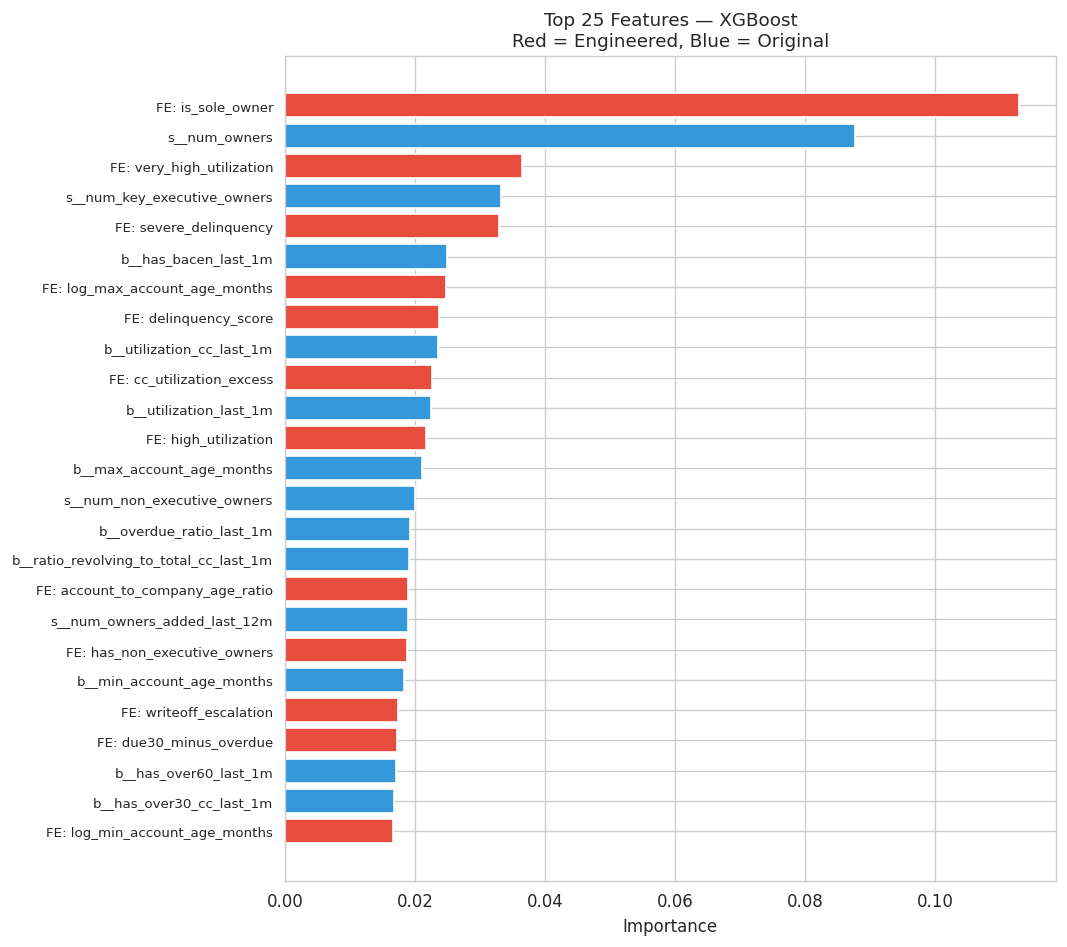

In [31]:
best_m = best_models[best_name]
best_m.fit(X, y)

if hasattr(best_m, 'feature_importances_'):
    importances = pd.Series(best_m.feature_importances_, index=all_features).sort_values()
elif hasattr(best_m, 'named_steps'):
    coefs = np.abs(best_m.named_steps['model'].coef_[0])
    importances = pd.Series(coefs, index=all_features).sort_values()

top_imp = importances.tail(25)
fig, ax = plt.subplots(figsize=(9, 8))
colors_feat = ['#e74c3c' if f.startswith('fe__') else '#3498db' for f in top_imp.index]
ax.barh(range(len(top_imp)), top_imp.values, color=colors_feat)
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels([f.replace('bacen__','b__').replace('serpro__','s__').replace('fe__','FE: ')
                     for f in top_imp.index], fontsize=8)
ax.set_title(f'Top 25 Features — {best_name}\nRed = Engineered, Blue = Original', fontsize=11)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Deployment Architecture

The proposed production architecture has three layers:

**Ingestion layer** — An API Gateway receives origination requests and orchestrates real-time queries to SERPRO and BACEN APIs for the 28 base variables. The feature engineering pipeline (33 derived variables) runs as a deterministic transformation in the same service. Caching with configurable TTL reduces latency and query costs.

**Scoring layer** — The serialized XGBoost model runs inside a FastAPI microservice (Docker container) returning: default probability, risk decile, and recommended decision (approve / reject / manual review). Target latency < 200ms. A champion/challenger framework tests new model versions in shadow mode before promotion.

**Monitoring layer** — Automated PSI (Population Stability Index) and CSI (Characteristic Stability Index) tracking over 30-day rolling windows to detect data drift. Gini and KS monitored in production against observed outcomes (6–12 month lag). Alerts fire if PSI > 0.25 or Gini drops more than 10% from baseline. Model versioning through MLflow with full traceability: data hash, hyperparameters, metrics, and feature set.

## Limitations and Next Steps

**Dataset constraints** — 1,000 observations with only 146 positive events yields an events-per-variable ratio of ~2.4, well below the recommended 10–20. This limits stability and generalization confidence despite aggressive regularization.

**Missing variables** — The dataset lacks revenue, cash flow, industry sector, geography, and macroeconomic indicators that typically strengthen origination scorecards.

**Selection bias** — Origination data only contains outcomes for approved applications. Rejected applicants are absent, biasing default probability estimates downward. Reject inference techniques should be applied before production deployment.

**Proposed improvements:**
- Enrich with alternative bureau data, electronic invoicing, and sectoral macro indicators
- Explore survival analysis to model time-to-default rather than binary occurrence
- Apply Platt scaling or isotonic regression for probability calibration
- Build segmented models for new vs. established companies
- Implement fairness metrics to detect discriminatory bias
- Periodic backtesting against realized outcomes